# 11 - Evaluate Silhouette GaitGL-style Expert - FULL FIXED

Run this after `10_train_silhouette_gaitgl_expert_FULL_FIXED.ipynb` finishes training.

It evaluates the silhouette-only GaitGL-style expert on CASIA-B LT:

```text
gallery_LT_fusion.csv
probe_LT_nm_fusion.csv
probe_LT_bg_fusion.csv
probe_LT_cl_fusion.csv
```

Evaluation method:

```text
embedding extraction -> cosine similarity -> identical-view exclusion -> Rank-1/5/10 + CMC
```

This notebook supports both checkpoint types saved by notebook 10:

```text
gaitgl_LT_silhouette_last.pth                 backbone-only
gaitgl_LT_silhouette_best_loss.pth            backbone-only
gaitgl_LT_silhouette_best_train_acc.pth       backbone-only
gaitgl_LT_silhouette_full_last.pth            full model with classifier
```

Important: gallery size is dynamic. It can be 2197, not exactly 2200.

In [1]:
# ============================================================
# CELL 1 - Imports, paths, config
# ============================================================

from pathlib import Path
import json
import time
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    from tqdm.notebook import tqdm
except Exception:
    try:
        from tqdm import tqdm
    except Exception:
        def tqdm(x, *args, **kwargs):
            return x

warnings.filterwarnings('ignore')

EXP_DIR = Path('/media/wadud/DriveUbuntu/GaitRecognition 2.0')
FUSION_SPLIT_DIR = EXP_DIR / 'data' / 'fusion_splits'
CHECKPOINT_DIR = EXP_DIR / 'checkpoints'
RESULT_DIR = EXP_DIR / 'results'

SPLIT_NAME = 'LT'
RUN_NAME = f'gaitgl_{SPLIT_NAME}_silhouette'

EVAL_ROOT = RESULT_DIR / 'gaitgl_silhouette_eval'
EMBED_DIR = EVAL_ROOT / 'embeddings'
PLOT_DIR = EVAL_ROOT / 'plots'
DETAIL_DIR = EVAL_ROOT / 'details'
for d in [EVAL_ROOT, EMBED_DIR, PLOT_DIR, DETAIL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

GALLERY_CSV = FUSION_SPLIT_DIR / f'gallery_{SPLIT_NAME}_fusion.csv'
PROBE_CSVS = {
    'NM': FUSION_SPLIT_DIR / f'probe_{SPLIT_NAME}_nm_fusion.csv',
    'BG': FUSION_SPLIT_DIR / f'probe_{SPLIT_NAME}_bg_fusion.csv',
    'CL': FUSION_SPLIT_DIR / f'probe_{SPLIT_NAME}_cl_fusion.csv',
}

CHECKPOINT_PATHS = [
    CHECKPOINT_DIR / f'{RUN_NAME}_last.pth',
    CHECKPOINT_DIR / f'{RUN_NAME}_best_loss.pth',
    CHECKPOINT_DIR / f'{RUN_NAME}_best_train_acc.pth',
    CHECKPOINT_DIR / f'{RUN_NAME}_full_last.pth',
]

# To evaluate only one checkpoint, use for example:
# CHECKPOINT_PATHS = [CHECKPOINT_DIR / 'gaitgl_LT_silhouette_last.pth']

SEQ_LEN = 60
SIL_H = 64
SIL_W = 44
NUM_EVAL_CLIPS = 5
EVAL_BATCH_SIZE = 32
NUM_WORKERS = 2
PIN_MEMORY = True
EXCLUDE_IDENTICAL_VIEW = True
TOPK = 10
SAVE_EMBEDDINGS = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
try:
    torch.set_float32_matmul_precision('high')
except Exception:
    pass

print('=' * 80)
print('Evaluate Silhouette GaitGL-style Expert')
print('=' * 80)
print('EXP_DIR:', EXP_DIR)
print('GALLERY_CSV:', GALLERY_CSV)
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
print('NUM_EVAL_CLIPS:', NUM_EVAL_CLIPS)
print('EXCLUDE_IDENTICAL_VIEW:', EXCLUDE_IDENTICAL_VIEW)
print('=' * 80)

assert GALLERY_CSV.exists(), f'Missing gallery CSV: {GALLERY_CSV}'
for name, path in PROBE_CSVS.items():
    assert path.exists(), f'Missing probe CSV for {name}: {path}'

Evaluate Silhouette GaitGL-style Expert
EXP_DIR: /media/wadud/DriveUbuntu/GaitRecognition 2.0
GALLERY_CSV: /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/gallery_LT_fusion.csv
Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
NUM_EVAL_CLIPS: 5
EXCLUDE_IDENTICAL_VIEW: True


In [2]:
# ============================================================
# CELL 2 - Load gallery/probe CSVs
# ============================================================

csv_dtype = {
    'subject': str,
    'condition': str,
    'seq': str,
    'view': str,
    'pose_path': str,
    'silhouette_path': str,
}

def load_eval_csv(path):
    df = pd.read_csv(path, dtype=csv_dtype)
    required = ['subject', 'condition', 'seq', 'view', 'silhouette_path']
    missing_cols = [c for c in required if c not in df.columns]
    assert not missing_cols, f'{path} missing columns: {missing_cols}'

    df = df.dropna(subset=['subject', 'silhouette_path']).copy()
    df['silhouette_path'] = df['silhouette_path'].astype(str)

    exists_mask = df['silhouette_path'].apply(lambda p: Path(p).exists())
    missing_paths = df[~exists_mask].copy()
    if len(missing_paths) > 0:
        out = DETAIL_DIR / f'{Path(path).stem}_missing_silhouette_paths.csv'
        missing_paths.to_csv(out, index=False)
        print('[WARNING]', path.name, 'missing paths:', len(missing_paths), 'saved:', out)

    return df[exists_mask].reset_index(drop=True)

df_gallery = load_eval_csv(GALLERY_CSV)
probe_dfs = {name: load_eval_csv(path) for name, path in PROBE_CSVS.items()}

print('Gallery rows:', len(df_gallery))
print('Gallery subjects:', df_gallery['subject'].nunique())
print('Gallery views:', sorted(df_gallery['view'].unique().tolist()))

for name, df in probe_dfs.items():
    print(f'{name} probe rows:', len(df), 'subjects:', df['subject'].nunique(), 'views:', sorted(df['view'].unique().tolist()))

display(df_gallery.head())

Gallery rows: 2197
Gallery subjects: 50
Gallery views: ['000', '018', '036', '054', '072', '090', '108', '126', '144', '162', '180']
NM probe rows: 1100 subjects: 50 views: ['000', '018', '036', '054', '072', '090', '108', '126', '144', '162', '180']
BG probe rows: 1100 subjects: 50 views: ['000', '018', '036', '054', '072', '090', '108', '126', '144', '162', '180']
CL probe rows: 1100 subjects: 50 views: ['000', '018', '036', '054', '072', '090', '108', '126', '144', '162', '180']


,split_pose_path,subject,condition,seq,view,pose_path,silhouette_path,T_pose,T_silhouette,T_common,T_diff,alignment_status,sil_valid_frame_ratio,sil_mean_det_score,sil_mean_mask_area
0,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,nm,01,000,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,115.0,115.0,115.0,0.0,exact,1.000000,0.917485,6296.843262
1,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,nm,01,018,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,125.0,125.0,125.0,0.0,exact,0.952000,0.864465,4692.624023
2,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,nm,01,036,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,127.0,127.0,127.0,0.0,exact,0.866142,0.783757,3219.110352
3,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,nm,01,054,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,129.0,129.0,129.0,0.0,exact,0.860465,0.770493,2610.627930
4,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,075,nm,01,072,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,124.0,124.0,124.0,0.0,exact,0.645161,0.573876,2274.258057


In [3]:
# ============================================================
# CELL 3 - Evaluation dataset and multi-clip maker
# ============================================================

def make_eval_clips(S, seq_len=60, num_clips=5):
    T = S.shape[0]
    if T <= 0:
        raise ValueError('Empty silhouette sequence')

    clips = []
    if T >= seq_len:
        if num_clips <= 1:
            starts = [max(0, (T - seq_len) // 2)]
        else:
            starts = np.linspace(0, T - seq_len, num=num_clips)
            starts = [int(round(x)) for x in starts]
        for st in starts:
            clips.append(S[st:st + seq_len])
    else:
        pad_len = seq_len - T
        pad = np.repeat(S[-1:], pad_len, axis=0)
        clip = np.concatenate([S, pad], axis=0)
        for _ in range(num_clips):
            clips.append(clip)

    return np.stack(clips, axis=0).astype(np.float32)

class SilhouetteEvalDataset(Dataset):
    def __init__(self, df, seq_len=60, num_clips=5):
        self.df = df.reset_index(drop=True).copy()
        self.seq_len = int(seq_len)
        self.num_clips = int(num_clips)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row['silhouette_path']
        data = np.load(path)
        S = data['silhouettes'].astype(np.float32)
        if S.max() > 1.5:
            S = S / 255.0
        clips = make_eval_clips(S, seq_len=self.seq_len, num_clips=self.num_clips)
        clips = np.ascontiguousarray(clips, dtype=np.float32)
        return {
            'clips': torch.from_numpy(clips),
            'subject': str(row['subject']),
            'condition': str(row['condition']),
            'seq': str(row['seq']),
            'view': str(row['view']),
            'silhouette_path': str(path),
        }

def make_eval_loader(df, batch_size=32):
    ds = SilhouetteEvalDataset(df, seq_len=SEQ_LEN, num_clips=NUM_EVAL_CLIPS)
    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )
    return ds, dl

sample = SilhouetteEvalDataset(df_gallery.iloc[:2], SEQ_LEN, NUM_EVAL_CLIPS)[0]
print('Eval clips shape:', sample['clips'].shape)
assert tuple(sample['clips'].shape) == (NUM_EVAL_CLIPS, SEQ_LEN, SIL_H, SIL_W)

Eval clips shape: torch.Size([5, 60, 64, 44])


In [4]:
# ============================================================
# CELL 4 - GaitGL-style backbone definition, same as notebook 10
# ============================================================

class ConvBNAct3D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), dropout=0.0):
        super().__init__()
        self.conv = nn.Conv3d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding, bias=False)
        self.bn = nn.BatchNorm3d(out_channels)
        self.act = nn.Mish()
        self.drop = nn.Dropout3d(dropout) if dropout > 0 else nn.Identity()
    def forward(self, x):
        return self.drop(self.act(self.bn(self.conv(x))))

class Residual3DBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=(1, 1, 1), dropout=0.0):
        super().__init__()
        self.conv1 = ConvBNAct3D(in_channels, out_channels, kernel_size=(3, 3, 3), stride=stride, padding=(1, 1, 1), dropout=dropout)
        self.conv2 = nn.Sequential(
            nn.Conv3d(out_channels, out_channels, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False),
            nn.BatchNorm3d(out_channels),
        )
        if in_channels != out_channels or stride != (1, 1, 1):
            self.shortcut = nn.Sequential(
                nn.Conv3d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm3d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()
        self.act = nn.Mish()
    def forward(self, x):
        return self.act(self.conv2(self.conv1(x)) + self.shortcut(x))

class HorizontalPyramidPooling3D(nn.Module):
    def __init__(self, bins=(1, 2, 4, 8)):
        super().__init__()
        self.bins = list(bins)
    def forward(self, x):
        B, C, T, H, W = x.shape
        part_features = []
        for bin_count in self.bins:
            for i in range(bin_count):
                h_start = int(round(i * H / bin_count))
                h_end = int(round((i + 1) * H / bin_count))
                h_end = max(h_end, h_start + 1)
                part = x[:, :, :, h_start:h_end, :]
                pooled = part.mean(dim=(2, 3, 4)) + part.amax(dim=(2, 3, 4))
                part_features.append(pooled)
        return torch.stack(part_features, dim=1)

class GaitGLLiteBackbone(nn.Module):
    def __init__(self, embedding_dim=256, channels=(32, 64, 128, 128), hpp_bins=(1, 2, 4, 8), dropout=0.1):
        super().__init__()
        c1, c2, c3, c4 = channels
        self.stem = nn.Sequential(
            ConvBNAct3D(1, c1, kernel_size=(3, 5, 5), padding=(1, 2, 2), dropout=0.0),
            Residual3DBlock(c1, c1, stride=(1, 1, 1), dropout=dropout),
        )
        self.layer1 = nn.Sequential(
            Residual3DBlock(c1, c2, stride=(1, 2, 2), dropout=dropout),
            Residual3DBlock(c2, c2, stride=(1, 1, 1), dropout=dropout),
        )
        self.layer2 = nn.Sequential(
            Residual3DBlock(c2, c3, stride=(1, 2, 2), dropout=dropout),
            Residual3DBlock(c3, c3, stride=(1, 1, 1), dropout=dropout),
        )
        self.layer3 = nn.Sequential(
            ConvBNAct3D(c3, c4, kernel_size=(3, 3, 3), padding=(1, 1, 1), dropout=dropout),
            Residual3DBlock(c4, c4, stride=(1, 1, 1), dropout=dropout),
        )
        self.hpp = HorizontalPyramidPooling3D(bins=hpp_bins)
        self.part_norm = nn.LayerNorm(c4)
        self.part_fc = nn.Linear(c4, embedding_dim, bias=False)
        self.embedding_bn = nn.BatchNorm1d(embedding_dim)
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        parts = self.hpp(x)
        parts = self.part_norm(parts)
        parts = self.part_fc(parts)
        emb = parts.mean(dim=1)
        emb = self.embedding_bn(emb)
        return F.normalize(emb, p=2, dim=1)

def build_backbone_from_config(config):
    embedding_dim = int(config.get('embedding_dim', 256))
    channels = config.get('channels', [32, 64, 128, 128])
    hpp_bins = config.get('hpp_bins', [1, 2, 4, 8])
    dropout = float(config.get('dropout', 0.10))
    backbone = GaitGLLiteBackbone(embedding_dim=embedding_dim, channels=channels, hpp_bins=hpp_bins, dropout=dropout)
    return backbone, embedding_dim

In [5]:
# ============================================================
# CELL 5 - Robust checkpoint loading
# ============================================================

def strip_prefix_if_present(state_dict, prefix):
    out = {}
    found = False
    for k, v in state_dict.items():
        if k.startswith(prefix):
            out[k[len(prefix):]] = v
            found = True
        else:
            out[k] = v
    return out, found

def extract_backbone_state_dict(raw_state):
    state = dict(raw_state)
    state, _ = strip_prefix_if_present(state, 'module.')
    has_backbone_prefix = any(k.startswith('backbone.') for k in state.keys())
    if has_backbone_prefix:
        state = {k[len('backbone.'):]: v for k, v in state.items() if k.startswith('backbone.')}
    state = {k: v for k, v in state.items() if not k.startswith('classifier.')}
    return state

def load_gaitgl_backbone(checkpoint_path):
    checkpoint_path = Path(checkpoint_path)
    ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    config = ckpt.get('config', {})
    backbone, embedding_dim = build_backbone_from_config(config)
    raw_state = ckpt['model']
    backbone_state = extract_backbone_state_dict(raw_state)
    missing, unexpected = backbone.load_state_dict(backbone_state, strict=False)
    if len(missing) > 0:
        print('[WARNING] Missing keys:', missing[:10], 'count:', len(missing))
    if len(unexpected) > 0:
        print('[WARNING] Unexpected keys:', unexpected[:10], 'count:', len(unexpected))
    if len(missing) > 0:
        raise RuntimeError(f'Checkpoint {checkpoint_path.name} missing backbone keys. Loading unsafe.')
    backbone = backbone.to(device)
    backbone.eval()
    meta = {
        'checkpoint_path': str(checkpoint_path),
        'checkpoint_name': checkpoint_path.name,
        'checkpoint_type': ckpt.get('checkpoint_type', 'unknown'),
        'step': int(ckpt.get('step', -1)),
        'best_loss': float(ckpt.get('best_loss', np.nan)),
        'best_acc': float(ckpt.get('best_acc', np.nan)),
        'embedding_dim': embedding_dim,
        'config': config,
    }
    return backbone, meta

CHECKPOINT_PATHS = [Path(p) for p in CHECKPOINT_PATHS if Path(p).exists()]
print('Checkpoints selected:')
for p in CHECKPOINT_PATHS:
    print('-', p.name)
assert len(CHECKPOINT_PATHS) > 0, 'No selected checkpoints exist.'

# Load-test first checkpoint.
test_backbone, test_meta = load_gaitgl_backbone(CHECKPOINT_PATHS[0])
print('Loaded test checkpoint:', test_meta)
with torch.no_grad():
    dummy = torch.randn(2, SEQ_LEN, SIL_H, SIL_W, device=device)
    emb = test_backbone(dummy)
    print('Dummy embedding:', emb.shape)
del test_backbone, dummy, emb
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Checkpoints selected:
- gaitgl_LT_silhouette_last.pth
- gaitgl_LT_silhouette_best_loss.pth
- gaitgl_LT_silhouette_best_train_acc.pth
- gaitgl_LT_silhouette_full_last.pth
Loaded test checkpoint: {'checkpoint_path': '/media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaitgl_LT_silhouette_last.pth', 'checkpoint_name': 'gaitgl_LT_silhouette_last.pth', 'checkpoint_type': 'eval_backbone_only_gaitgl_silhouette', 'step': 29999, 'best_loss': 0.8325570225715637, 'best_acc': 1.0, 'embedding_dim': 256, 'config': {'seq_len': 60, 'sil_h': 64, 'sil_w': 44, 'embedding_dim': 256, 'channels': [32, 64, 128, 128], 'hpp_bins': [1, 2, 4, 8], 'dropout': 0.1, 'run_name': 'gaitgl_LT_silhouette'}}
Dummy embedding: torch.Size([2, 256])


In [6]:
# ============================================================
# CELL 6 - Embedding extraction
# ============================================================

@torch.no_grad()
def extract_embeddings(backbone, df, split_name, checkpoint_stem):
    ds, dl = make_eval_loader(df, batch_size=EVAL_BATCH_SIZE)
    all_embs = []
    all_rows = []
    start_time = time.time()
    for batch in tqdm(dl, desc=f'Extract {split_name} embeddings'):
        clips = batch['clips'].float().to(device, non_blocking=True)
        B, N, T, H, W = clips.shape
        clip_embs = []
        for clip_i in range(N):
            x = clips[:, clip_i]
            emb = backbone(x)
            clip_embs.append(emb)
        emb = torch.stack(clip_embs, dim=1).mean(dim=1)
        emb = F.normalize(emb, p=2, dim=1)
        all_embs.append(emb.detach().cpu().numpy().astype(np.float32))
        for i in range(B):
            all_rows.append({
                'subject': batch['subject'][i],
                'condition': batch['condition'][i],
                'seq': batch['seq'][i],
                'view': batch['view'][i],
                'silhouette_path': batch['silhouette_path'][i],
            })
    embs = np.concatenate(all_embs, axis=0)
    meta_df = pd.DataFrame(all_rows)
    elapsed = time.time() - start_time
    print(f'{split_name}: embeddings={embs.shape}, rows={len(meta_df)}, elapsed={elapsed/60:.2f} min')
    if SAVE_EMBEDDINGS:
        out_npz = EMBED_DIR / f'{checkpoint_stem}_{split_name}_embeddings.npz'
        out_csv = EMBED_DIR / f'{checkpoint_stem}_{split_name}_meta.csv'
        np.savez_compressed(out_npz, embeddings=embs)
        meta_df.to_csv(out_csv, index=False)
        print('Saved:', out_npz)
        print('Saved:', out_csv)
    return embs, meta_df

In [7]:
# ============================================================
# CELL 7 - Ranking metrics with identical-view exclusion
# ============================================================

def compute_cmc_and_details(gallery_emb, gallery_df, probe_emb, probe_df, condition_name, checkpoint_name, topk=10, exclude_identical_view=True):
    gallery_subjects = gallery_df['subject'].astype(str).values
    gallery_views = gallery_df['view'].astype(str).values
    probe_subjects = probe_df['subject'].astype(str).values
    probe_views = probe_df['view'].astype(str).values

    G = gallery_emb.astype(np.float32)
    P = probe_emb.astype(np.float32)
    G = G / np.maximum(np.linalg.norm(G, axis=1, keepdims=True), 1e-12)
    P = P / np.maximum(np.linalg.norm(P, axis=1, keepdims=True), 1e-12)
    sim = P @ G.T

    num_probe = P.shape[0]
    cmc_hits = np.zeros((topk,), dtype=np.float64)
    detail_rows = []
    valid_queries = 0

    for i in range(num_probe):
        scores = sim[i].copy()
        if exclude_identical_view:
            invalid = gallery_views == probe_views[i]
            scores[invalid] = -1e9
        valid_gallery_count = int(np.sum(scores > -1e8))
        if valid_gallery_count <= 0:
            detail_rows.append({
                'checkpoint': checkpoint_name,
                'condition': condition_name,
                'probe_index': i,
                'probe_subject': probe_subjects[i],
                'probe_view': probe_views[i],
                'valid_gallery_count': valid_gallery_count,
                'rank1_correct': np.nan,
                'rank': np.nan,
                'top1_subject': '',
                'top1_view': '',
                'top1_score': np.nan,
            })
            continue
        ranked = np.argsort(-scores)[:min(topk, len(scores))]
        ranked_subjects = gallery_subjects[ranked]
        correct_mask = ranked_subjects == probe_subjects[i]
        if correct_mask.any():
            first_rank = int(np.where(correct_mask)[0][0]) + 1
            for k in range(first_rank - 1, topk):
                cmc_hits[k] += 1.0
        else:
            first_rank = np.nan
        valid_queries += 1
        top1_idx = ranked[0]
        detail_rows.append({
            'checkpoint': checkpoint_name,
            'condition': condition_name,
            'probe_index': i,
            'probe_subject': probe_subjects[i],
            'probe_condition': probe_df.iloc[i]['condition'],
            'probe_seq': probe_df.iloc[i]['seq'],
            'probe_view': probe_views[i],
            'valid_gallery_count': valid_gallery_count,
            'rank1_correct': bool(correct_mask[0]),
            'rank': first_rank,
            'top1_subject': gallery_subjects[top1_idx],
            'top1_view': gallery_views[top1_idx],
            'top1_score': float(scores[top1_idx]),
            'probe_silhouette_path': probe_df.iloc[i]['silhouette_path'],
        })
    cmc = cmc_hits / max(1, valid_queries)
    details_df = pd.DataFrame(detail_rows)
    summary = {
        'checkpoint': checkpoint_name,
        'condition': condition_name,
        'num_probe': int(num_probe),
        'valid_queries': int(valid_queries),
        'num_gallery': int(len(gallery_df)),
        'exclude_identical_view': bool(exclude_identical_view),
        'rank1': float(cmc[0]) if topk >= 1 else np.nan,
        'rank5': float(cmc[4]) if topk >= 5 else np.nan,
        'rank10': float(cmc[9]) if topk >= 10 else np.nan,
    }
    return summary, cmc, details_df

def summarize_by_probe_view(details_df):
    rows = []
    for view, g in details_df.groupby('probe_view'):
        valid = g['rank1_correct'].dropna()
        rows.append({'probe_view': view, 'num_probe': int(len(g)), 'rank1': float(valid.astype(float).mean()) if len(valid) else np.nan})
    return pd.DataFrame(rows).sort_values('probe_view')

def summarize_by_subject(details_df):
    rows = []
    for subject, g in details_df.groupby('probe_subject'):
        valid = g['rank1_correct'].dropna()
        rows.append({'subject': subject, 'num_probe': int(len(g)), 'rank1': float(valid.astype(float).mean()) if len(valid) else np.nan})
    return pd.DataFrame(rows).sort_values('subject')

In [8]:
# ============================================================
# CELL 8 - Evaluate one checkpoint
# ============================================================

def evaluate_checkpoint(checkpoint_path):
    checkpoint_path = Path(checkpoint_path)
    checkpoint_stem = checkpoint_path.stem
    print('\n' + '=' * 80)
    print('Evaluating checkpoint:', checkpoint_path.name)
    print('=' * 80)
    backbone, meta = load_gaitgl_backbone(checkpoint_path)
    gallery_emb, gallery_meta = extract_embeddings(backbone, df_gallery, f'gallery_{SPLIT_NAME}', checkpoint_stem)

    condition_summaries = []
    cmc_by_condition = {}
    detail_dfs = []

    for condition_name, probe_df in probe_dfs.items():
        probe_emb, probe_meta = extract_embeddings(backbone, probe_df, f'probe_{SPLIT_NAME}_{condition_name.lower()}', checkpoint_stem)
        summary, cmc, details_df = compute_cmc_and_details(
            gallery_emb=gallery_emb,
            gallery_df=gallery_meta,
            probe_emb=probe_emb,
            probe_df=probe_meta,
            condition_name=condition_name,
            checkpoint_name=checkpoint_path.name,
            topk=TOPK,
            exclude_identical_view=EXCLUDE_IDENTICAL_VIEW,
        )
        condition_summaries.append(summary)
        cmc_by_condition[condition_name] = cmc
        detail_dfs.append(details_df)

        details_csv = DETAIL_DIR / f'{checkpoint_stem}_{condition_name}_probe_details.csv'
        details_df.to_csv(details_csv, index=False)
        summarize_by_probe_view(details_df).to_csv(DETAIL_DIR / f'{checkpoint_stem}_{condition_name}_by_probe_view.csv', index=False)
        summarize_by_subject(details_df).to_csv(DETAIL_DIR / f'{checkpoint_stem}_{condition_name}_by_subject.csv', index=False)

        print(f"{condition_name}: Rank-1={summary['rank1']*100:.2f}%, Rank-5={summary['rank5']*100:.2f}%, Rank-10={summary['rank10']*100:.2f}%")

    summary_df = pd.DataFrame(condition_summaries)
    summary_df['rank1_percent'] = summary_df['rank1'] * 100.0
    summary_df['rank5_percent'] = summary_df['rank5'] * 100.0
    summary_df['rank10_percent'] = summary_df['rank10'] * 100.0
    mean_rank1 = float(summary_df['rank1'].mean())
    mean_rank5 = float(summary_df['rank5'].mean())
    mean_rank10 = float(summary_df['rank10'].mean())
    summary_df['mean_rank1_across_conditions'] = mean_rank1
    summary_df['mean_rank5_across_conditions'] = mean_rank5
    summary_df['mean_rank10_across_conditions'] = mean_rank10

    summary_csv = EVAL_ROOT / f'{checkpoint_stem}_summary.csv'
    summary_df.to_csv(summary_csv, index=False)

    detail_all = pd.concat(detail_dfs, ignore_index=True)
    detail_all_csv = DETAIL_DIR / f'{checkpoint_stem}_all_probe_details.csv'
    detail_all.to_csv(detail_all_csv, index=False)

    cmc_json = EVAL_ROOT / f'{checkpoint_stem}_cmc.json'
    with open(cmc_json, 'w') as f:
        json.dump({'checkpoint': checkpoint_path.name, 'topk': TOPK, 'conditions': {k: v.tolist() for k, v in cmc_by_condition.items()}}, f, indent=2)

    plt.figure(figsize=(8, 5))
    for condition_name, cmc in cmc_by_condition.items():
        plt.plot(np.arange(1, TOPK + 1), cmc * 100.0, marker='o', label=condition_name)
    plt.xlabel('Rank')
    plt.ylabel('CMC Accuracy (%)')
    plt.title(f'CMC - {checkpoint_path.name}')
    plt.grid(True, alpha=0.3)
    plt.xticks(np.arange(1, TOPK + 1))
    plt.legend()
    cmc_plot = PLOT_DIR / f'{checkpoint_stem}_cmc.png'
    plt.savefig(cmc_plot, dpi=150, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.bar(summary_df['condition'], summary_df['rank1_percent'])
    plt.ylim(0, 100)
    plt.ylabel('Rank-1 (%)')
    plt.title(f'Rank-1 by Condition - {checkpoint_path.name}')
    plt.grid(axis='y', alpha=0.3)
    rank1_plot = PLOT_DIR / f'{checkpoint_stem}_rank1_bar.png'
    plt.savefig(rank1_plot, dpi=150, bbox_inches='tight')
    plt.show()

    checkpoint_summary = {
        'checkpoint': checkpoint_path.name,
        'checkpoint_path': str(checkpoint_path),
        'checkpoint_type': meta['checkpoint_type'],
        'step': meta['step'],
        'best_loss': meta['best_loss'],
        'best_acc': meta['best_acc'],
        'num_gallery': int(len(df_gallery)),
        'num_probe_NM': int(len(probe_dfs['NM'])),
        'num_probe_BG': int(len(probe_dfs['BG'])),
        'num_probe_CL': int(len(probe_dfs['CL'])),
        'rank1_NM': float(summary_df[summary_df['condition'] == 'NM']['rank1'].iloc[0]),
        'rank1_BG': float(summary_df[summary_df['condition'] == 'BG']['rank1'].iloc[0]),
        'rank1_CL': float(summary_df[summary_df['condition'] == 'CL']['rank1'].iloc[0]),
        'rank5_NM': float(summary_df[summary_df['condition'] == 'NM']['rank5'].iloc[0]),
        'rank5_BG': float(summary_df[summary_df['condition'] == 'BG']['rank5'].iloc[0]),
        'rank5_CL': float(summary_df[summary_df['condition'] == 'CL']['rank5'].iloc[0]),
        'mean_rank1': mean_rank1,
        'mean_rank5': mean_rank5,
        'mean_rank10': mean_rank10,
        'summary_csv': str(summary_csv),
        'detail_csv': str(detail_all_csv),
        'cmc_json': str(cmc_json),
        'cmc_plot': str(cmc_plot),
        'rank1_plot': str(rank1_plot),
    }

    del backbone
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return checkpoint_summary, summary_df


Evaluating checkpoint: gaitgl_LT_silhouette_last.pth


Extract gallery_LT embeddings:   0%|          | 0/69 [00:00<?, ?it/s]

gallery_LT: embeddings=(2197, 256), rows=2197, elapsed=3.28 min
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_last_gallery_LT_embeddings.npz
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_last_gallery_LT_meta.csv


Extract probe_LT_nm embeddings:   0%|          | 0/35 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x791c67303f40>
Traceback (most recent call last):
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x791c67303f40>
Traceback (most recent call last):
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/home/wadud/miniconda

...

Extract probe_LT_bg embeddings:   0%|          | 0/35 [00:00<?, ?it/s]

probe_LT_bg: embeddings=(1100, 256), rows=1100, elapsed=1.48 min
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_last_probe_LT_bg_embeddings.npz
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_last_probe_LT_bg_meta.csv
BG: Rank-1=85.64%, Rank-5=94.45%, Rank-10=96.36%


Extract probe_LT_cl embeddings:   0%|          | 0/35 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x791c67303f40>
Traceback (most recent call last):
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x791c67303f40>
Traceback (most recent call last):
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/home/wadud/miniconda

probe_LT_cl: embeddings=(1100, 256), rows=1100, elapsed=1.64 min
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_last_probe_LT_cl_embeddings.npz
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_last_probe_LT_cl_meta.csv
CL: Rank-1=65.55%, Rank-5=81.82%, Rank-10=88.91%


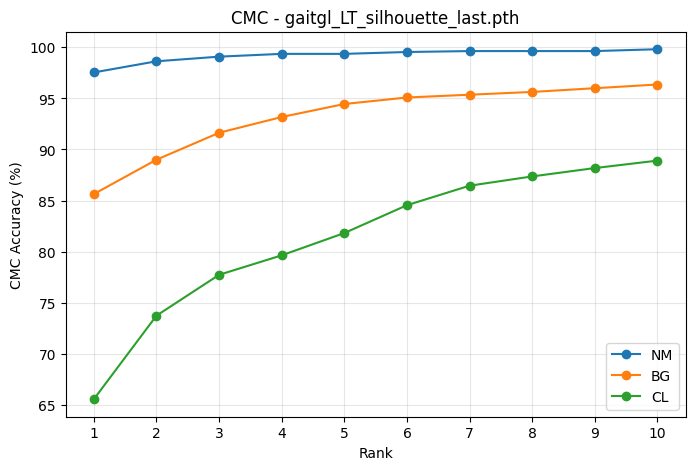

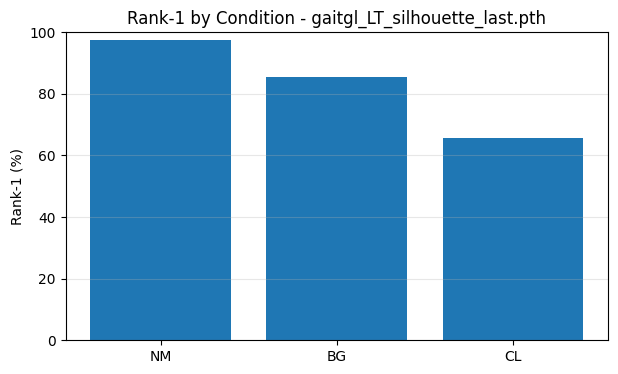


Evaluating checkpoint: gaitgl_LT_silhouette_best_loss.pth


Extract gallery_LT embeddings:   0%|          | 0/69 [00:00<?, ?it/s]

gallery_LT: embeddings=(2197, 256), rows=2197, elapsed=3.32 min
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_best_loss_gallery_LT_embeddings.npz
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_best_loss_gallery_LT_meta.csv


Extract probe_LT_nm embeddings:   0%|          | 0/35 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x791c67303f40>
Traceback (most recent call last):
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x791c67303f40>
Traceback (most recent call last):
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/home/wadud/miniconda

...

Extract probe_LT_bg embeddings:   0%|          | 0/35 [00:00<?, ?it/s]

probe_LT_bg: embeddings=(1100, 256), rows=1100, elapsed=1.61 min
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_best_loss_probe_LT_bg_embeddings.npz
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_best_loss_probe_LT_bg_meta.csv
BG: Rank-1=85.45%, Rank-5=94.27%, Rank-10=96.09%


Extract probe_LT_cl embeddings:   0%|          | 0/35 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x791c67303f40>
Traceback (most recent call last):
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x791c67303f40>
Traceback (most recent call last):
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/home/wadud/miniconda

probe_LT_cl: embeddings=(1100, 256), rows=1100, elapsed=1.47 min
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_best_loss_probe_LT_cl_embeddings.npz
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_best_loss_probe_LT_cl_meta.csv
CL: Rank-1=65.91%, Rank-5=83.00%, Rank-10=89.00%


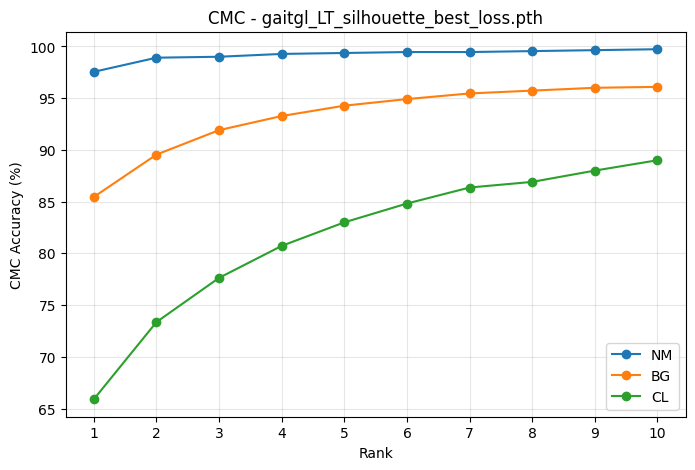

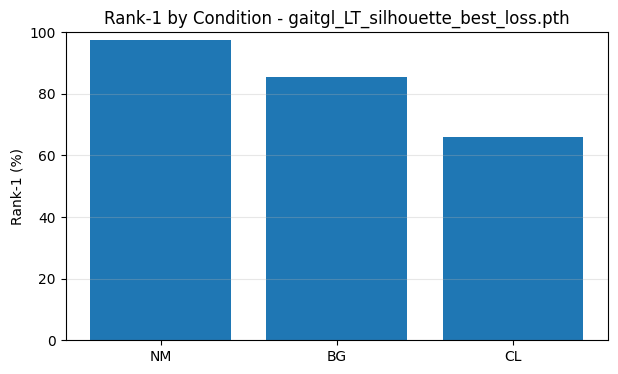


Evaluating checkpoint: gaitgl_LT_silhouette_best_train_acc.pth


Extract gallery_LT embeddings:   0%|          | 0/69 [00:00<?, ?it/s]

gallery_LT: embeddings=(2197, 256), rows=2197, elapsed=3.32 min
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_best_train_acc_gallery_LT_embeddings.npz
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_best_train_acc_gallery_LT_meta.csv


Extract probe_LT_nm embeddings:   0%|          | 0/35 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x791c67303f40>
Traceback (most recent call last):
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x791c67303f40>
Traceback (most recent call last):
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/home/wadud/miniconda

...

Extract probe_LT_bg embeddings:   0%|          | 0/35 [00:00<?, ?it/s]

probe_LT_bg: embeddings=(1100, 256), rows=1100, elapsed=1.50 min
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_best_train_acc_probe_LT_bg_embeddings.npz
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_best_train_acc_probe_LT_bg_meta.csv
BG: Rank-1=65.82%, Rank-5=77.91%, Rank-10=84.73%


Extract probe_LT_cl embeddings:   0%|          | 0/35 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x791c67303f40>
Traceback (most recent call last):
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x791c67303f40>
Traceback (most recent call last):
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/home/wadud/miniconda

probe_LT_cl: embeddings=(1100, 256), rows=1100, elapsed=1.56 min
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_best_train_acc_probe_LT_cl_embeddings.npz
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_best_train_acc_probe_LT_cl_meta.csv
CL: Rank-1=45.73%, Rank-5=64.27%, Rank-10=73.73%


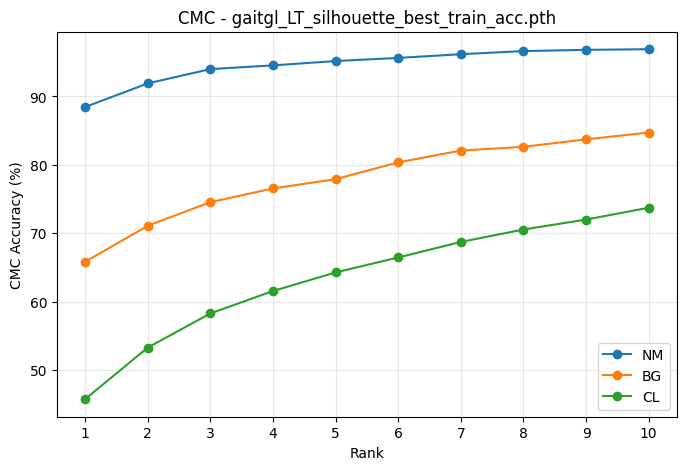

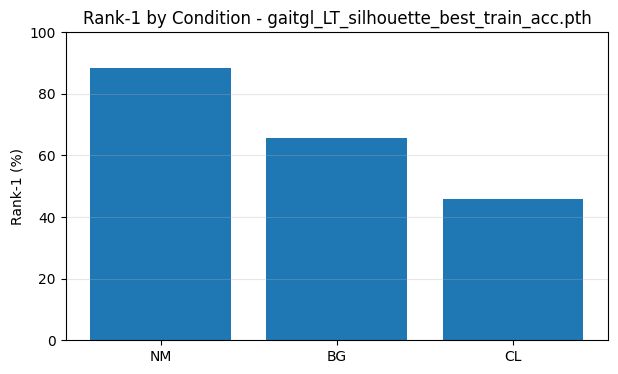


Evaluating checkpoint: gaitgl_LT_silhouette_full_last.pth


Extract gallery_LT embeddings:   0%|          | 0/69 [00:00<?, ?it/s]

gallery_LT: embeddings=(2197, 256), rows=2197, elapsed=2.96 min
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_full_last_gallery_LT_embeddings.npz
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_full_last_gallery_LT_meta.csv


Extract probe_LT_nm embeddings:   0%|          | 0/35 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x791c67303f40>
Traceback (most recent call last):
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x791c67303f40>
Traceback (most recent call last):
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/home/wadud/miniconda

...

Extract probe_LT_bg embeddings:   0%|          | 0/35 [00:00<?, ?it/s]

probe_LT_bg: embeddings=(1100, 256), rows=1100, elapsed=1.76 min
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_full_last_probe_LT_bg_embeddings.npz
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_full_last_probe_LT_bg_meta.csv
BG: Rank-1=85.64%, Rank-5=94.45%, Rank-10=96.36%


Extract probe_LT_cl embeddings:   0%|          | 0/35 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x791c67303f40>
Traceback (most recent call last):
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x791c67303f40>
Traceback (most recent call last):
  File "/home/wadud/miniconda3/envs/gait_fusion/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/home/wadud/miniconda

probe_LT_cl: embeddings=(1100, 256), rows=1100, elapsed=1.46 min
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_full_last_probe_LT_cl_embeddings.npz
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/embeddings/gaitgl_LT_silhouette_full_last_probe_LT_cl_meta.csv
CL: Rank-1=65.55%, Rank-5=81.82%, Rank-10=88.91%


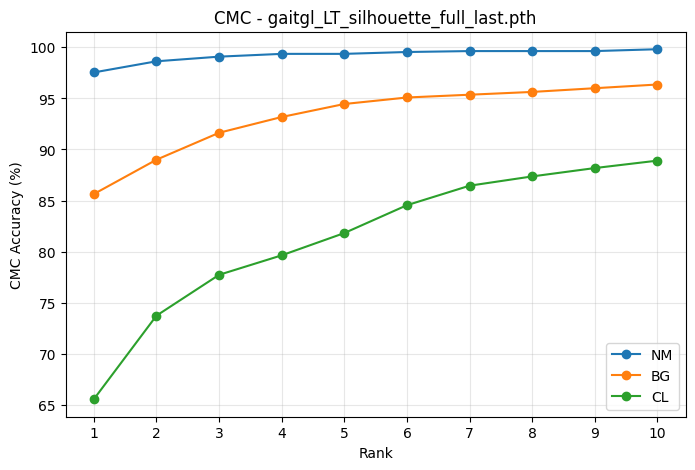

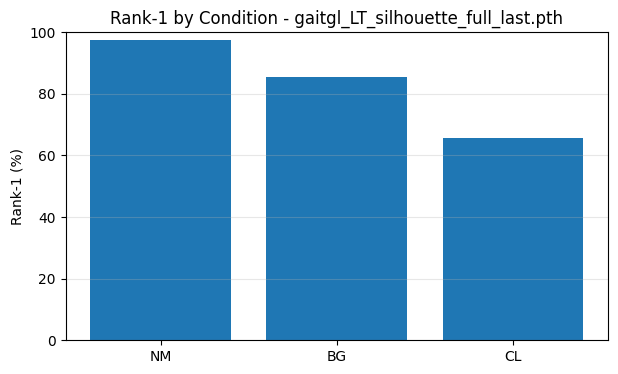

Checkpoint comparison:


,checkpoint,step,rank1_NM_percent,rank1_BG_percent,rank1_CL_percent,mean_rank1_percent,rank5_NM,rank5_BG,rank5_CL
0,gaitgl_LT_silhouette_best_loss.pth,27846,97.545455,85.454545,65.909091,82.969697,0.993636,0.942727,0.830000
1,gaitgl_LT_silhouette_last.pth,29999,97.545455,85.636364,65.545455,82.909091,0.993636,0.944545,0.818182
2,gaitgl_LT_silhouette_full_last.pth,29999,97.545455,85.636364,65.545455,82.909091,0.993636,0.944545,0.818182
3,gaitgl_LT_silhouette_best_train_acc.pth,4800,88.454545,65.818182,45.727273,66.666667,0.951818,0.779091,0.642727


Saved comparison: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/gaitgl_LT_silhouette_checkpoint_comparison.csv
Saved condition table: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/gaitgl_LT_silhouette_all_checkpoint_condition_summary.csv
Best checkpoint: gaitgl_LT_silhouette_best_loss.pth
Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/gaitgl_LT_silhouette_best_eval_checkpoint.txt


In [9]:
# ============================================================
# CELL 9 - Run checkpoint comparison
# ============================================================

all_checkpoint_summaries = []
all_condition_tables = []

for ckpt_path in CHECKPOINT_PATHS:
    ckpt_summary, condition_table = evaluate_checkpoint(ckpt_path)
    all_checkpoint_summaries.append(ckpt_summary)
    tmp = condition_table.copy()
    tmp['checkpoint_name'] = ckpt_path.name
    all_condition_tables.append(tmp)

comparison_df = pd.DataFrame(all_checkpoint_summaries)
comparison_df['rank1_NM_percent'] = comparison_df['rank1_NM'] * 100.0
comparison_df['rank1_BG_percent'] = comparison_df['rank1_BG'] * 100.0
comparison_df['rank1_CL_percent'] = comparison_df['rank1_CL'] * 100.0
comparison_df['mean_rank1_percent'] = comparison_df['mean_rank1'] * 100.0
comparison_df = comparison_df.sort_values('mean_rank1', ascending=False).reset_index(drop=True)

comparison_csv = EVAL_ROOT / f'{RUN_NAME}_checkpoint_comparison.csv'
comparison_df.to_csv(comparison_csv, index=False)

condition_all_df = pd.concat(all_condition_tables, ignore_index=True)
condition_all_csv = EVAL_ROOT / f'{RUN_NAME}_all_checkpoint_condition_summary.csv'
condition_all_df.to_csv(condition_all_csv, index=False)

print('Checkpoint comparison:')
display(comparison_df[[
    'checkpoint', 'step',
    'rank1_NM_percent', 'rank1_BG_percent', 'rank1_CL_percent', 'mean_rank1_percent',
    'rank5_NM', 'rank5_BG', 'rank5_CL',
]])
print('Saved comparison:', comparison_csv)
print('Saved condition table:', condition_all_csv)

best_row = comparison_df.iloc[0]
best_txt = EVAL_ROOT / f'{RUN_NAME}_best_eval_checkpoint.txt'
best_txt.write_text(
    f"Best checkpoint by mean Rank-1: {best_row['checkpoint']}\n"
    f"NM Rank-1: {best_row['rank1_NM_percent']:.4f}\n"
    f"BG Rank-1: {best_row['rank1_BG_percent']:.4f}\n"
    f"CL Rank-1: {best_row['rank1_CL_percent']:.4f}\n"
    f"Mean Rank-1: {best_row['mean_rank1_percent']:.4f}\n",
    encoding='utf-8',
)
print('Best checkpoint:', best_row['checkpoint'])
print('Saved:', best_txt)

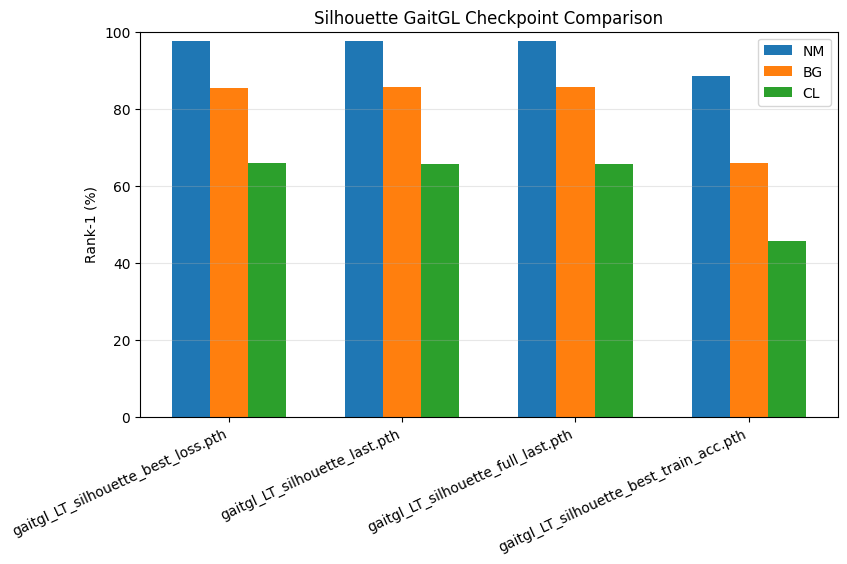

Saved: /media/wadud/DriveUbuntu/GaitRecognition 2.0/results/gaitgl_silhouette_eval/plots/gaitgl_LT_silhouette_checkpoint_comparison_rank1.png


In [10]:
# ============================================================
# CELL 10 - Plot checkpoint comparison
# ============================================================

if len(comparison_df) > 0:
    x = np.arange(len(comparison_df))
    width = 0.22
    labels = comparison_df['checkpoint'].tolist()
    plt.figure(figsize=(max(9, len(labels) * 2.2), 5))
    plt.bar(x - width, comparison_df['rank1_NM_percent'], width, label='NM')
    plt.bar(x, comparison_df['rank1_BG_percent'], width, label='BG')
    plt.bar(x + width, comparison_df['rank1_CL_percent'], width, label='CL')
    plt.xticks(x, labels, rotation=25, ha='right')
    plt.ylabel('Rank-1 (%)')
    plt.ylim(0, 100)
    plt.title('Silhouette GaitGL Checkpoint Comparison')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    out_plot = PLOT_DIR / f'{RUN_NAME}_checkpoint_comparison_rank1.png'
    plt.savefig(out_plot, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', out_plot)

In [11]:
# ============================================================
# CELL 11 - Final summary JSON
# ============================================================

final_summary = {
    'run_name': RUN_NAME,
    'split_name': SPLIT_NAME,
    'gallery_csv': str(GALLERY_CSV),
    'probe_csvs': {k: str(v) for k, v in PROBE_CSVS.items()},
    'num_gallery': int(len(df_gallery)),
    'num_probe': {k: int(len(v)) for k, v in probe_dfs.items()},
    'num_eval_clips': int(NUM_EVAL_CLIPS),
    'seq_len': int(SEQ_LEN),
    'exclude_identical_view': bool(EXCLUDE_IDENTICAL_VIEW),
    'topk': int(TOPK),
    'checkpoint_paths': [str(p) for p in CHECKPOINT_PATHS],
    'comparison_csv': str(comparison_csv),
    'condition_all_csv': str(condition_all_csv),
    'best_checkpoint': str(comparison_df.iloc[0]['checkpoint']) if len(comparison_df) else '',
    'best_mean_rank1': float(comparison_df.iloc[0]['mean_rank1']) if len(comparison_df) else np.nan,
}
summary_json = EVAL_ROOT / f'{RUN_NAME}_evaluation_summary.json'
with open(summary_json, 'w') as f:
    json.dump(final_summary, f, indent=2)
print('=' * 80)
print('FINAL EVALUATION SUMMARY')
print('=' * 80)
print(json.dumps(final_summary, indent=2))
print('=' * 80)
print('Saved:', summary_json)

FINAL EVALUATION SUMMARY
{
  "run_name": "gaitgl_LT_silhouette",
  "split_name": "LT",
  "gallery_csv": "/media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/gallery_LT_fusion.csv",
  "probe_csvs": {
    "NM": "/media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/probe_LT_nm_fusion.csv",
    "BG": "/media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/probe_LT_bg_fusion.csv",
    "CL": "/media/wadud/DriveUbuntu/GaitRecognition 2.0/data/fusion_splits/probe_LT_cl_fusion.csv"
  },
  "num_gallery": 2197,
  "num_probe": {
    "NM": 1100,
    "BG": 1100,
    "CL": 1100
  },
  "num_eval_clips": 5,
  "seq_len": 60,
  "exclude_identical_view": true,
  "topk": 10,
  "checkpoint_paths": [
    "/media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaitgl_LT_silhouette_last.pth",
    "/media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaitgl_LT_silhouette_best_loss.pth",
    "/media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaitgl_LT_silhouette_best_

## After evaluation

Main files:

```text
results/gaitgl_silhouette_eval/gaitgl_LT_silhouette_checkpoint_comparison.csv
results/gaitgl_silhouette_eval/gaitgl_LT_silhouette_best_eval_checkpoint.txt
```

Next workflow:

```text
Silhouette GaitGL result
+
Skeleton GaitTR result
-> compare experts
-> train adaptive/gated fusion
```